# Partial Search Graph Materialisation

In this study we consider the operation of materialising successors in the search graph of selectable conjunction extents. Each node in this graph can be idenfied with

1. a selectable extent $I' \subseteq I = \{1,\dots, n\}$, i.e., there is at least one conjunctive query $q \in \mathcal Q$ such that $I_q=I'$,
2. a unique closure $Q=\{p \in \mathcal P \, : \, I' \subseteq I_p\}$ corresponding to the most specific conjunction that selects $I'$,
3. a unique canonical key, which is the lexicographically minimal $q$ such that $I_{q}=I'$

The third characterisation depends on some arbitrary but fixed order $\mathcal P =\{p_1, \dots, p_k\}$ This allows us to identify conjunctions with the index set of propositions contained in them, i.e.,
$$
q \sqsubseteq q' \equiv q=q' \text{ or } \min q \Delta q' \in q \enspace .
$$

Two such nodes representing distinct extensions $I_q' \subset I_q$ are naturally connected by a directed edge if there is a single proposition $p$ such that $I_{q'} = I_{qp}$. This edge relation is natural in the sense that out-edges can be easily and efficiently enumerated if one has access to the closure $C$ of a node or its complement, because every $p \not\in C$ corresponds to an out-edge of the search graph.

However, to enable an efficient node search one has to avoid exploring node subsets multiple times. The two main approaches to do this are:

1. Explicitly maintaining the set of already visited nodes, typically in a hash set
2. Use only a subset of canonical edges that induces a spanning tree of the full search graph and that can be locally filtered out of the set of all candidate out-edges of a node

The main challenge for the first approach is to define computationally efficient hash values. When working with a propositionalisation of $d$ numeric variables, it is possible to work with $O(d)$ keys representing the closure. We might explore this option, but if so only at a later stage, mainly because of difficulties implementing it with numba.

## Canonical Edges

An edge $(q, qp)$ is called canonical if both $q$ and $qp$ are canonical keys. The canonical edges induce a spanning tree of the search graph, hence, they are an attractive choice for performing an efficient search within the graph that avoids exploring node subsets multiple times. 

Unfortunately, the canonical out-edges from a given node are not given explicitly. The standard strategy is to test each edge given by a $p \in \mathcal P \setminus C(q) \cap \{\max q,\dots, k\}$ for canonicity.

In [1]:
import numpy as np
from testdata import mvn_with_correlation

# RNG = np.random.default_rng(seed=0)
# x = RNG.multivariate_normal([0, 0, 0], [[1, 0.5, -0.5],[0.5, 1, -0.5], [-0.5, -0.5, 1]], size=100)
x = mvn_with_correlation(100)
x

array([[-1.80295844e-01, -5.40094120e-02, -2.42441699e-01,
         4.05730312e-01],
       [ 6.44914668e-01, -2.68527664e-02, -1.27483260e+00,
         1.98959207e-01],
       [-2.18557675e-01,  7.15768579e-01, -5.63746386e-01,
        -1.16444892e+00],
       [ 1.70411624e+00,  2.14506935e+00, -1.06565736e+00,
        -2.43754993e+00],
       [ 2.36581009e-01, -4.37372050e-02, -1.07480412e+00,
        -4.53450098e-01],
       [ 9.38400137e-01, -4.56373127e-01,  3.26061293e-01,
        -2.50496575e-01],
       [-6.56685353e-01, -3.03284022e-01,  1.40875819e+00,
         4.88296006e-01],
       [ 4.96705462e-01,  3.12598114e-01,  1.96439798e-01,
        -8.34592375e-01],
       [ 4.57077351e-01, -1.59099101e-01, -2.45013979e-01,
         3.94785366e-02],
       [ 4.37525085e-01, -2.04617194e-01, -1.45737935e+00,
        -3.77300363e-01],
       [ 1.92246389e+00,  4.08473986e-01, -1.56525171e+00,
        -8.53252195e-02],
       [-4.01308212e-01, -1.07476381e+00, -1.23845445e+00,
      

In [2]:
from opticon import equal_width_propositionalization

prop = equal_width_propositionalization(x)
len(prop)

70

In [10]:
def prop_to_string(prop, j):
    return f'x{prop.v[j]+1} {'>=' if prop.s[j]==1 else '<='} {prop.s[j]*prop.t[j]:0.3f}'

In [12]:
prop_to_string(prop, 0), prop_to_string(prop, 1), prop_to_string(prop, 2)

('x1 >= -1.472', 'x1 >= -1.013', 'x1 >= -0.554')

In [13]:
x[15:20, 0]

array([-0.37132209, -0.41841603, -1.85007793, -1.17209056,  1.09558266])

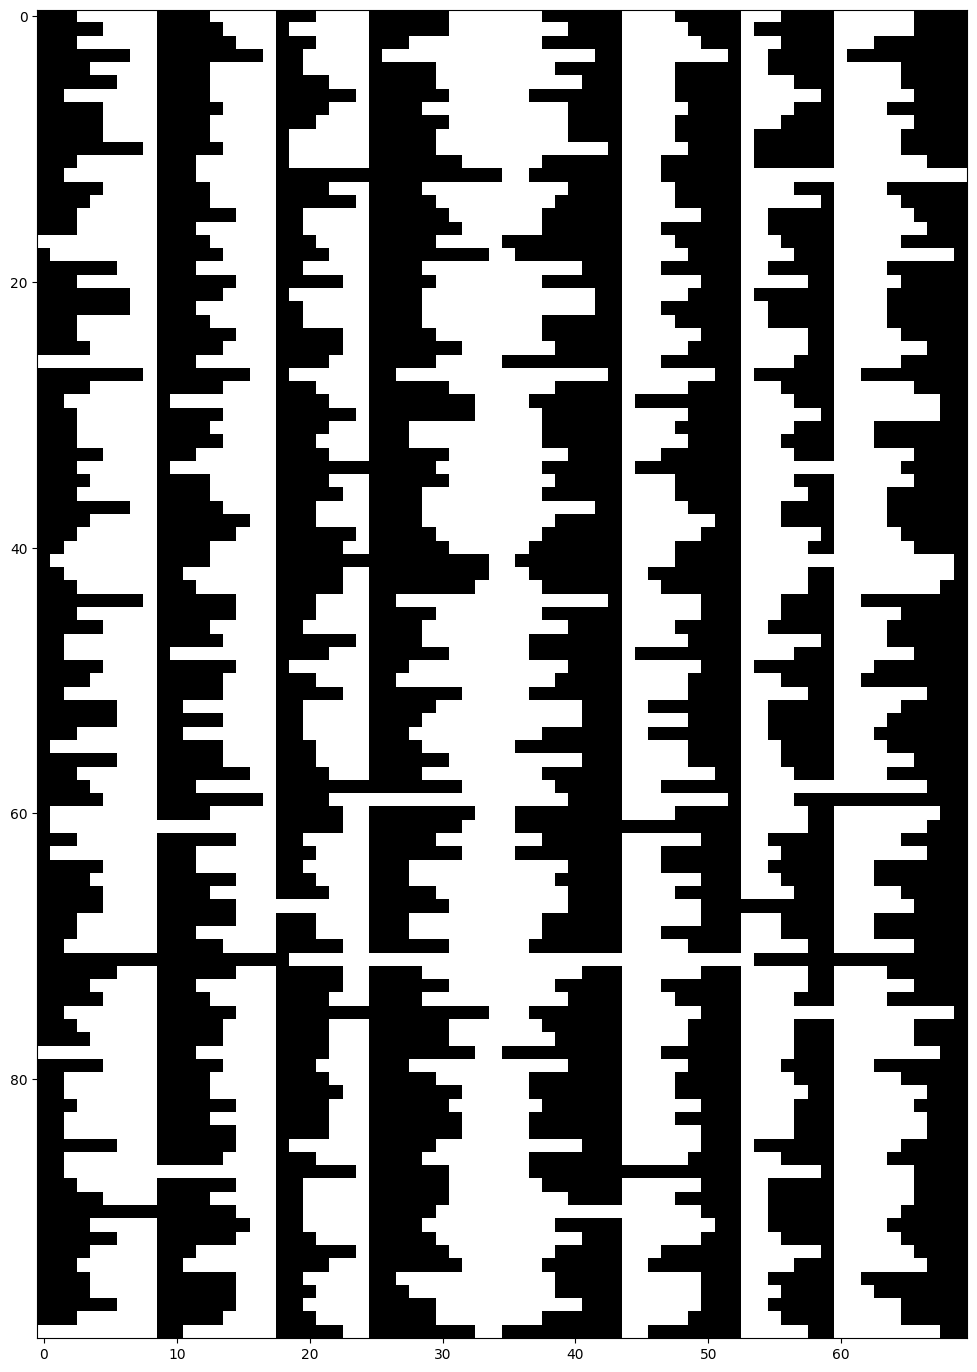

In [3]:
from matplotlib import pyplot as plt

binary = prop.binarize(x)
plt.figure(figsize=(12, 20))
plt.imshow(binary, cmap='Greys', interpolation='none')
plt.show()

In [48]:
# from numba.types import int32, float64
# from numba.experimental import jitclass

# @jitclass
# class Propositionalization:

#     v: int32[:]
#     t: float64[:]
#     s: int32[:]

#     def __init__(self, v, t, s):
#         self.v = v
#         self.t = t
#         self.s = s

#     def support(self, p, x):
#         return np.flatnonzero(self.s[p]*x[:,self.v[p]] >= self.t[p])
    
#     def binarize(self, x):
#         return self.s*x[:, self.v] >= self.t
    
#     def implied(self, p, x, l=None, u=None):
#         l = np.min(x[:, self.v[p]])
#         u = np.max(x[:, self.v[p]])
#         if self.s[p]==1:
#             return l >= self.t[p]
#         else:
#             return -u >= self.t[p]
        
#     # def critical(self, q, x):
#     #     j = 0
#     #     for p in q:
#     #         while j < p:
#     #             if self.implied(j, x):
#     #                 return j
#     #             j = j + 1
#     #         j = j + 1
#     #     return -1

# def to_string(prop, j):
#     return f'x{prop.v[j]+1} {'>=' if prop.s[j]==1 else '<='} {prop.s[j]*prop.t[j]:0.3f}'

def extent_vectorized(prop, q, x):
    q = np.atleast_1d(q)
    return np.flatnonzero(np.prod(prop.s[q]*x[:, prop.v[q]] >= prop.t[q], axis=1, dtype=bool))

def tautologies_vectorized(prop, x, subset=None):
    subset = subset if subset is not None else np.arange(len(prop.v))
    l=np.min(x, axis=0)
    u=np.max(x, axis=0)

    res = np.zeros(len(prop.v[subset]), dtype=bool)
    np.greater_equal(l[prop.v[subset]], prop.t[subset], where=prop.s[subset]==1, out=res)
    np.greater_equal(-u[prop.v[subset]], prop.t[subset], where=prop.s[subset]==-1, out=res)

    return np.flatnonzero(res)

def nontrivial_vectorised(prop, x, subset=None):
    subset = subset if subset is not None else np.arange(len(prop.v))
    l=np.min(x, axis=0)
    u=np.max(x, axis=0)

    res = np.zeros(len(prop.v[subset]), dtype=bool)
    np.less(l[prop.v[subset]], prop.t[subset], where=prop.s[subset]==1, out=res)
    np.less(-u[prop.v[subset]], prop.t[subset], where=prop.s[subset]==-1, out=res)

    return np.flatnonzero(res)

In [23]:
root_key = np.array([], dtype=np.int64)
root_sup = extent_vectorized(prop, root_key, x)
root_closure = tautologies_vectorized(prop, x[root_sup])
root_remaining = nontrivial_vectorised(prop, x[root_sup])
root_remaining

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69])

In [27]:
from numba.types import int64
from numba.experimental import jitclass
from opticon import Propositionalization

@jitclass
class Node:

    key: int64[:]
    critical: int64[:]
    remaining: int64[:]
    support: int64[:]
    prop: Propositionalization

    def __init__(self, prop, key, critical, remaining, support):
        self.prop = prop
        self.key = key
        self.critical = critical
        self.remaining =remaining
        self.support = support

def node_to_string(node):
    return f'Node({node.key})'

root = Node(prop, root_key, np.empty(0, dtype=np.int64), root_remaining, root_sup)
node_to_string(root), root.critical, root.remaining

('Node([])',
 array([], dtype=int64),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
        51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
        68, 69]))

In [ ]:
def tautologies_vectorized(prop, x, subset=None):
    subset = subset if subset is not None else np.arange(len(prop.v))
    l=np.min(x, axis=0)
    u=np.max(x, axis=0)

    res = np.zeros(len(prop.v[subset]), dtype=bool)
    np.greater_equal(l[prop.v[subset]], prop.t[subset], where=prop.s[subset]==1, out=res)
    np.greater_equal(-u[prop.v[subset]], prop.t[subset], where=prop.s[subset]==-1, out=res)

    return np.flatnonzero(res)

def nontrivial_vectorised(prop, x, subset=None):
    subset = subset if subset is not None else np.arange(len(prop.v))
    l=np.min(x, axis=0)
    u=np.max(x, axis=0)

    res = np.zeros(len(prop.v[subset]), dtype=bool)
    np.less(l[prop.v[subset]], prop.t[subset], where=prop.s[subset]==1, out=res)
    np.less(-u[prop.v[subset]], prop.t[subset], where=prop.s[subset]==-1, out=res)

    return np.flatnonzero(res)

def refinement_naive(node, x):
    res = []
    for p_idx in range(len(node.remaining)):
        p = node.remaining[p_idx]
        _key = np.append(node.key, p)
        _sup = node.prop.support(p, x[node.support])
        _crit = np.append(node.critical, node.remaining[:p_idx])
        if len(tautologies_vectorized(node.prop, x[_sup], _crit))>0: #canonicity check
            continue
        _remaining = nontrivial_vectorised(prop, x[_sup], subset=node.remaining[p_idx+1:])
        res.append(Node(node.prop, _key, _crit, _remaining, _sup))
    return res
    
refs = refinement_naive(root, x)
len(refs)

15

In [47]:
%timeit refinement_naive(root, x)

1.44 ms ± 12.3 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [54]:
from numba import njit, int64, boolean
from numba.typed import List
import numpy as np

@njit
def compute_bounds(x):
    n, p = x.shape
    l = np.empty(p)
    u = np.empty(p)
    for j in range(p):
        l[j] = x[0, j]
        u[j] = x[0, j]
    for i in range(1, n):
        for j in range(p):
            if x[i, j] < l[j]:
                l[j] = x[i, j]
            if x[i, j] > u[j]:
                u[j] = x[i, j]
    return l, u

@njit
def tautologies(prop, l, u, subset):
    idxs = prop.v[subset]
    tvals = prop.t[subset]
    svals = prop.s[subset]

    res = np.zeros(len(subset), dtype=np.bool_)

    mask1 = svals == 1
    mask2 = svals == -1

    res[mask1] = l[idxs[mask1]] >= tvals[mask1]
    res[mask2] = -u[idxs[mask2]] >= tvals[mask2]

    return res.nonzero()[0]

@njit
def nontrivial(prop, l, u, subset):
    idxs = prop.v[subset]
    tvals = prop.t[subset]
    svals = prop.s[subset]

    res = np.zeros(len(subset), dtype=np.bool_)

    mask1 = svals == 1
    mask2 = svals == -1

    res[mask1] = l[idxs[mask1]] < tvals[mask1]
    res[mask2] = -u[idxs[mask2]] < tvals[mask2]

    return res.nonzero()[0]

@njit
def refinement(node, x):
    res = List()
    for p_idx in range(len(node.remaining)):
        p = node.remaining[p_idx]
        _key = np.append(node.key, p)
        _sup = node.prop.support(p, x[node.support])
        _crit = np.append(node.critical, node.remaining[:p_idx])
        l, u = compute_bounds(x[_sup])
        if len(tautologies(node.prop, l, u, _crit))>0: #canonicity check
            continue
        _remaining = nontrivial(node.prop, l, u, node.remaining[p_idx+1:])
        res.append(Node(node.prop, _key, _crit, _remaining, _sup))
    return res


In [56]:
refs = refinement(root, x)
len(refs)

15

In [ ]:
%timeit refinement(root, x)

In [17]:
def simple_refinement_vectorised(node, p, prop, x):
    _key = np.append(node.key, p)
    _sup = prop.support(p, x[node.support])
    _closure = tautologies_vectorized(prop, x[_sup])
    return Node(_key, _closure, _sup)

def inefficient_canonicity_check(node, refinement):
    return np.setdiff1d(refinement.closure, node.closure)[0]==refinement.key[-1]
    # critical index = node.closure 

refs = simple_refinement_vectorised(root, 13, prop, x)
# inefficient_canonicity_check(root, ref)
refs.closure

array([ 0,  9, 10, 11, 12, 13, 69])

In [19]:
np.searchsorted(np.array([10, 20, 30, 40]), 19)

np.int64(1)

In [ ]:
def canonical_successors(node, prop, x):
    for p in range(node.key[-1], len(prop)):
        if node.closure[np.searchsorted(node.closure, p)] != p:
            

In [9]:
%timeit simple_refinement_vectorised(root, 10, prop, x)

21 μs ± 243 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [16]:
%timeit simple_refinement_vectorised(root, 10, prop, x)

23.9 μs ± 53.7 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [50]:
%timeit simple_refinement_vectorised(root, 10, prop, x)

22.6 μs ± 244 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
